In [ ]:
import qiskit
print(qiskit.__version__)

2.4.1


In [ ]:


import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml
from pennylane import numpy as np
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

import sys
from pathlib import Path

project_root = Path("/Users/Dev/Documents/GitHub/Quantum-Machine-Learning-")
data_reupload_path = project_root / "data-re upload"

sys.path.append(str(data_reupload_path))
from models.LSTMAE_pipeline import (
    LSTMAEConfig,
    train_lstm_ae_latent_pipeline,
    plot_training_history,
    plot_reconstructed_series,
    plot_latent_trajectories,
)

In [16]:


file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"
df = pd.read_csv(file_path)

train_end_idx = 434

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

df_train shape: (434, 17)
df_test shape: (105, 17)


In [17]:
lstm_config = LSTMAEConfig(
    value_col=4,
    window_size=20,
    latent_dim=6,
    train_window_end=350,
    batch_size=16,
    n_epochs=1500,
    learning_rate=0.005,
    dropout_ratio=0.0,

    scaler_type="fixed_range",
    scaler_feature_range=(-1.0, 1.0),
    fixed_min=0.0,
    fixed_max=400.0,
    clip_fixed_scaler=False,

    use_act=False,
    device="cpu",
    save_path="lstm_ae_encoder_rainfall_fixed_scaler.pth",
    print_every=50,
)

lstm_results = train_lstm_ae_latent_pipeline(
    df=df_train,
    config=lstm_config,
    fit_scaler_in_train=True,
)

Epoch [50/1500] Train Loss: 0.048064 Val Loss: 0.056026
Epoch [100/1500] Train Loss: 0.042022 Val Loss: 0.049069
Epoch [150/1500] Train Loss: 0.040094 Val Loss: 0.047112
Epoch [200/1500] Train Loss: 0.038403 Val Loss: 0.049340
Epoch [250/1500] Train Loss: 0.035236 Val Loss: 0.047980
Epoch [300/1500] Train Loss: 0.034079 Val Loss: 0.048044
Epoch [350/1500] Train Loss: 0.032916 Val Loss: 0.048149
Epoch [400/1500] Train Loss: 0.031367 Val Loss: 0.044766
Epoch [450/1500] Train Loss: 0.030668 Val Loss: 0.044268
Epoch [500/1500] Train Loss: 0.029233 Val Loss: 0.044516
Epoch [550/1500] Train Loss: 0.028993 Val Loss: 0.045251
Epoch [600/1500] Train Loss: 0.027966 Val Loss: 0.045971
Epoch [650/1500] Train Loss: 0.027083 Val Loss: 0.046243
Epoch [700/1500] Train Loss: 0.026774 Val Loss: 0.045097
Epoch [750/1500] Train Loss: 0.025990 Val Loss: 0.046391
Epoch [800/1500] Train Loss: 0.025617 Val Loss: 0.045838
Epoch [850/1500] Train Loss: 0.025279 Val Loss: 0.046588
Epoch [900/1500] Train Loss: 0.0

In [18]:
print("X_train shape:", lstm_results["X_train"].shape)
print("X_val shape:", lstm_results["X_val"].shape)

print("z_train shape:", lstm_results["z_train"].shape)
print("z_val shape:", lstm_results["z_val"].shape)

print("y_train shape:", lstm_results["y_train"].shape)
print("y_val shape:", lstm_results["y_val"].shape)

print("Model:")
print(lstm_results["model"])
print("decoder.use_act:", lstm_results["model"].decoder.use_act)

X_train shape: (350, 20, 1)
X_val shape: (64, 20, 1)
z_train shape: (350, 6)
z_val shape: (64, 6)
y_train shape: (350, 1)
y_val shape: (64, 1)
Model:
LSTMAE(
  (encoder): Encoder(
    (lstm_enc): LSTM(1, 6, batch_first=True)
  )
  (decoder): Decoder(
    (act): Tanh()
    (lstm_dec): LSTM(6, 6, batch_first=True)
    (fc): Linear(in_features=6, out_features=1, bias=True)
  )
)
decoder.use_act: False


In [19]:


X_train = lstm_results["X_train"]
X_val = lstm_results["X_val"]

X_train_reconstructed = lstm_results["X_train_reconstructed"]
X_val_reconstructed = lstm_results["X_val_reconstructed"]

train_mse = np.mean((X_train - X_train_reconstructed) ** 2)
val_mse = np.mean((X_val - X_val_reconstructed) ** 2)

train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)

train_corr = np.corrcoef(
    X_train.reshape(-1),
    X_train_reconstructed.reshape(-1)
)[0, 1]

val_corr = np.corrcoef(
    X_val.reshape(-1),
    X_val_reconstructed.reshape(-1)
)[0, 1]

print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Train Corr:", train_corr)

print("Val MSE:", val_mse)
print("Val RMSE:", val_rmse)
print("Val Corr:", val_corr)

Train MSE: 0.030099569
Train RMSE: 0.17349227
Train Corr: 0.849309456203108
Val MSE: 0.043885995
Val RMSE: 0.20948984
Val Corr: 0.7926731518596511


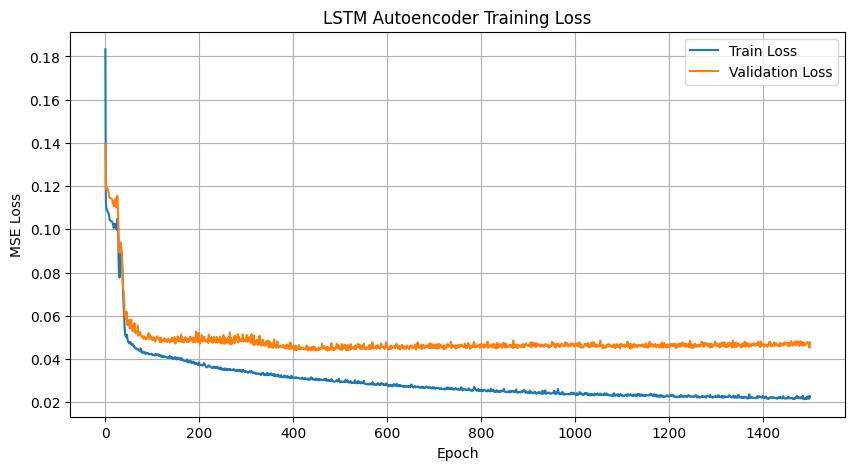

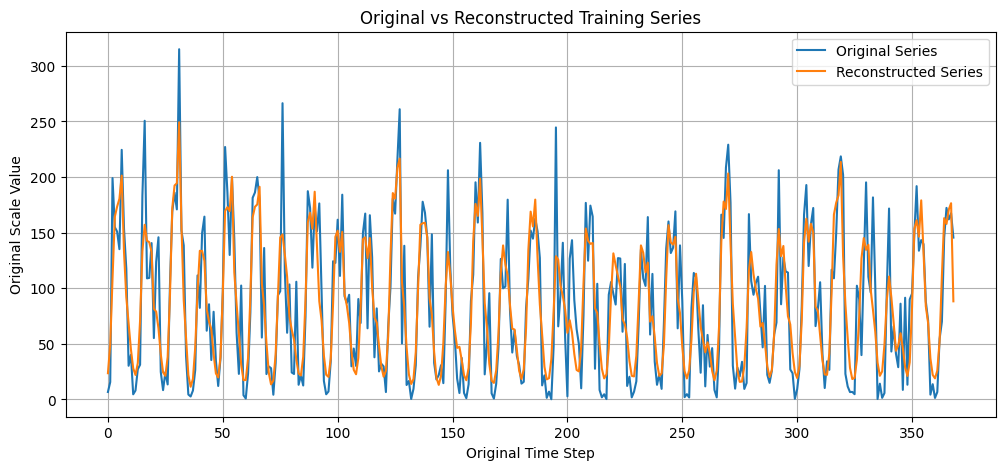

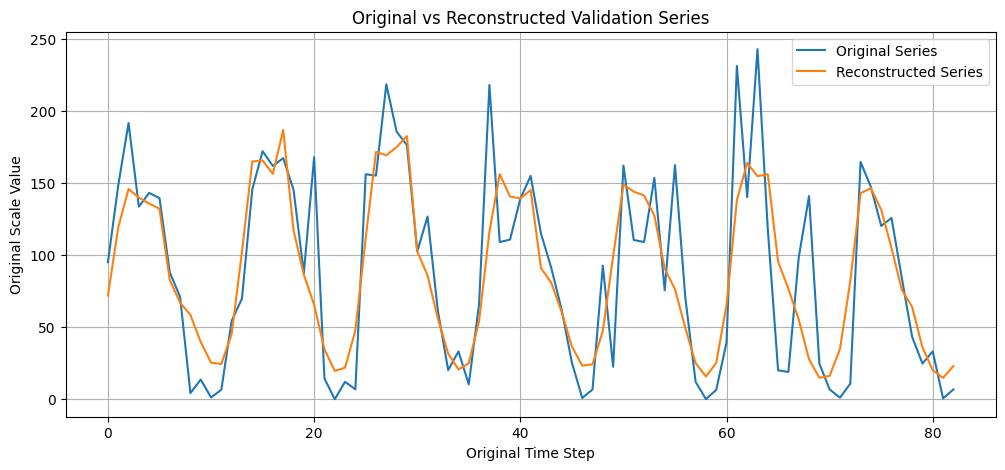

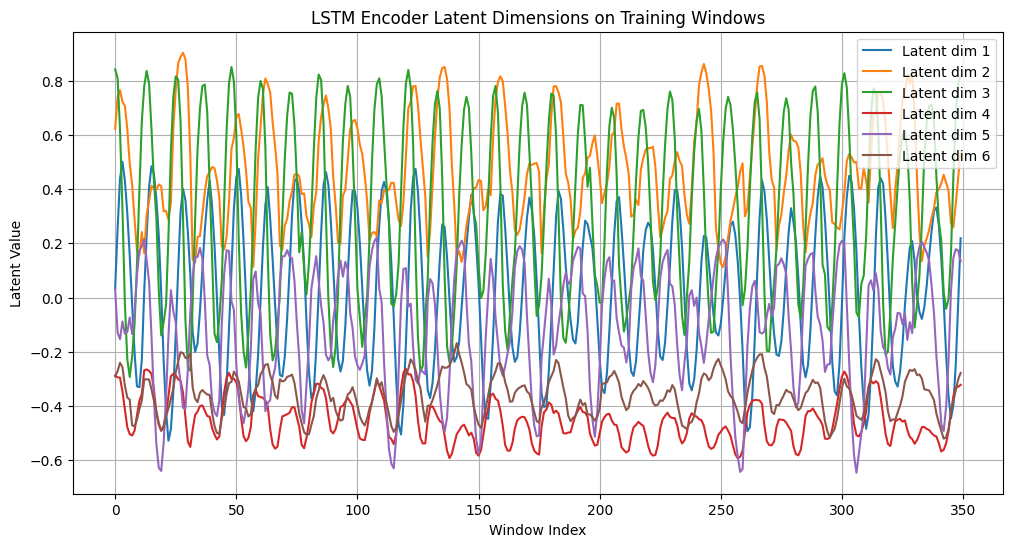

In [20]:


plot_training_history(lstm_results["history"])

plot_reconstructed_series(
    original_windows=lstm_results["X_train"],
    reconstructed_windows=lstm_results["X_train_reconstructed"],
    scaler=lstm_results["scaler"],
    title="Original vs Reconstructed Training Series",
)

plot_reconstructed_series(
    original_windows=lstm_results["X_val"],
    reconstructed_windows=lstm_results["X_val_reconstructed"],
    scaler=lstm_results["scaler"],
    title="Original vs Reconstructed Validation Series",
)

plot_latent_trajectories(
    lstm_results["z_train"],
    title="LSTM Encoder Latent Dimensions on Training Windows",
)

In [21]:


z_train = lstm_results["z_train"]
z_val = lstm_results["z_val"]

y_train = lstm_results["y_train"].reshape(-1)
y_val = lstm_results["y_val"].reshape(-1)

print("z_train shape:", z_train.shape)
print("z_val shape:", z_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

# Map LSTM latent vectors to quantum rotation angles.
# z has shape: (num_windows, 6)
# angles will also have shape: (num_windows, 6)
X_qnn_train = np.pi * z_train
X_qnn_val = np.pi * z_val

X_qnn_train_torch = torch.tensor(X_qnn_train, dtype=torch.float64)
X_qnn_val_torch = torch.tensor(X_qnn_val, dtype=torch.float64)

y_qnn_train_torch = torch.tensor(y_train, dtype=torch.float64)
y_qnn_val_torch = torch.tensor(y_val, dtype=torch.float64)

print("X_qnn_train_torch:", X_qnn_train_torch.shape)
print("X_qnn_val_torch:", X_qnn_val_torch.shape)
print("y_qnn_train_torch:", y_qnn_train_torch.shape)
print("y_qnn_val_torch:", y_qnn_val_torch.shape)

z_train shape: (350, 6)
z_val shape: (64, 6)
y_train shape: (350,)
y_val shape: (64,)
X_qnn_train_torch: torch.Size([350, 6])
X_qnn_val_torch: torch.Size([64, 6])
y_qnn_train_torch: torch.Size([350])
y_qnn_val_torch: torch.Size([64])


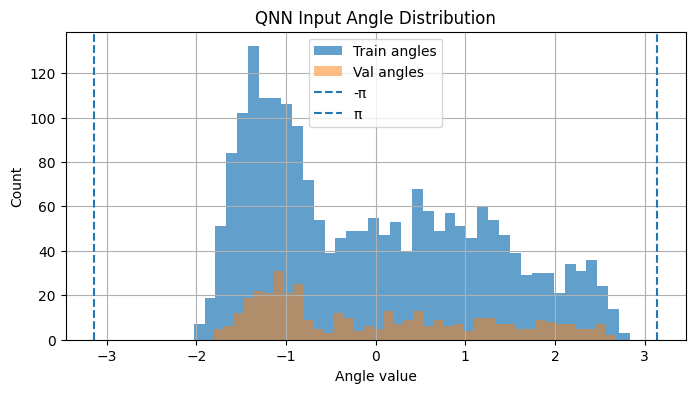

In [25]:
# =========================
# HISTOGRAM OF ALL ANGLES
# =========================

plt.figure(figsize=(8, 4))
plt.hist(X_qnn_train.flatten(), bins=40, alpha=0.7, label="Train angles")
plt.hist(X_qnn_val.flatten(), bins=40, alpha=0.5, label="Val angles")
plt.axvline(-np.pi, linestyle="--", label="-π")
plt.axvline(np.pi, linestyle="--", label="π")
plt.xlabel("Angle value")
plt.ylabel("Count")
plt.title("QNN Input Angle Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [26]:

# QNN DATALOADERS


from torch.utils.data import TensorDataset, DataLoader

qnn_batch_size = 32

qnn_train_dataset = TensorDataset(X_qnn_train_torch, y_qnn_train_torch)
qnn_val_dataset = TensorDataset(X_qnn_val_torch, y_qnn_val_torch)

qnn_train_loader = DataLoader(
    qnn_train_dataset,
    batch_size=qnn_batch_size,
    shuffle=True,
)

qnn_val_loader = DataLoader(
    qnn_val_dataset,
    batch_size=qnn_batch_size,
    shuffle=False,
)

In [27]:
# =========================
# QUANTUM CIRCUIT SETUP
# =========================

import pennylane as qml

n_ansatz_layers = 1
n_layers = 5
n_qubits = 6

dev_parallel = qml.device("default.qubit", wires=n_qubits)


def S(x):
    for w in range(n_qubits):
        qml.RY(x[w], wires=w)


def W(theta):
    for l in range(n_ansatz_layers):
        for w in range(n_qubits):
            qml.Rot(
                theta[l, w, 0],
                theta[l, w, 1],
                theta[l, w, 2],
                wires=w,
            )

        for w in range(n_qubits - 1):
            qml.CNOT(wires=[w, w + 1])

        qml.CNOT(wires=[n_qubits - 1, 0])


@qml.qnode(dev_parallel, interface="torch")
def circuit_parallel(params, x):
    for l in range(n_layers):
        S(x)
        W(params[l])

    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [28]:

# HYBRID QNN MODEL


class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.q_params = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_ansatz_layers,
                n_qubits,
                3,
                dtype=torch.float64,
            )
        )

        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 1),
            nn.Tanh(),
        ).double()

    def forward(self, x_batch):
        q_outputs = []

        for x in x_batch:
            q_out = circuit_parallel(self.q_params, x)

            # q_out is a list of n_qubits scalar tensors.
            q_out = torch.stack(q_out)

            q_outputs.append(q_out)

        # Shape: (batch_size, n_qubits)
        q_outputs = torch.stack(q_outputs)

        y_pred = self.classical(q_outputs)

        return y_pred.squeeze(-1)

In [29]:

# INITIALIZE QNN MODEL


device = torch.device("cpu")

hybrid_model = HybridModel().to(device)

criterion = nn.MSELoss()


optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.005)

print(hybrid_model)

HybridModel(
  (classical): Sequential(
    (0): Linear(in_features=6, out_features=1, bias=True)
    (1): Tanh()
  )
)


In [30]:

# QNN TRAINING LOOP


n_epochs_qnn = 200

train_losses_qnn = []
val_losses_qnn = []

best_val_loss_qnn = float("inf")
best_qnn_state = None

for epoch in range(n_epochs_qnn):
    hybrid_model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in qnn_train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = hybrid_model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = total_train_loss / len(qnn_train_loader.dataset)

    hybrid_model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in qnn_val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = hybrid_model(X_batch)

            loss = criterion(y_pred, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

    avg_val_loss = total_val_loss / len(qnn_val_loader.dataset)

    train_losses_qnn.append(avg_train_loss)
    val_losses_qnn.append(avg_val_loss)

    if avg_val_loss < best_val_loss_qnn:
        best_val_loss_qnn = avg_val_loss
        best_qnn_state = copy.deepcopy(hybrid_model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{n_epochs_qnn}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Val Loss: {avg_val_loss:.6f}"
        )

hybrid_model.load_state_dict(best_qnn_state)

print("Best QNN validation loss:", best_val_loss_qnn)

Epoch [10/200] Train Loss: 0.090689 Val Loss: 0.109783
Epoch [20/200] Train Loss: 0.052804 Val Loss: 0.082701
Epoch [30/200] Train Loss: 0.044811 Val Loss: 0.079623
Epoch [40/200] Train Loss: 0.041389 Val Loss: 0.081506
Epoch [50/200] Train Loss: 0.039203 Val Loss: 0.084877
Epoch [60/200] Train Loss: 0.037822 Val Loss: 0.088152
Epoch [70/200] Train Loss: 0.036877 Val Loss: 0.088834
Epoch [80/200] Train Loss: 0.036459 Val Loss: 0.090897
Epoch [90/200] Train Loss: 0.035430 Val Loss: 0.091611
Epoch [100/200] Train Loss: 0.034752 Val Loss: 0.090707
Epoch [110/200] Train Loss: 0.033994 Val Loss: 0.090676
Epoch [120/200] Train Loss: 0.033499 Val Loss: 0.090900
Epoch [130/200] Train Loss: 0.032852 Val Loss: 0.090788
Epoch [140/200] Train Loss: 0.032411 Val Loss: 0.092204
Epoch [150/200] Train Loss: 0.032099 Val Loss: 0.093436
Epoch [160/200] Train Loss: 0.031899 Val Loss: 0.092037
Epoch [170/200] Train Loss: 0.031795 Val Loss: 0.093003
Epoch [180/200] Train Loss: 0.031222 Val Loss: 0.094456
E

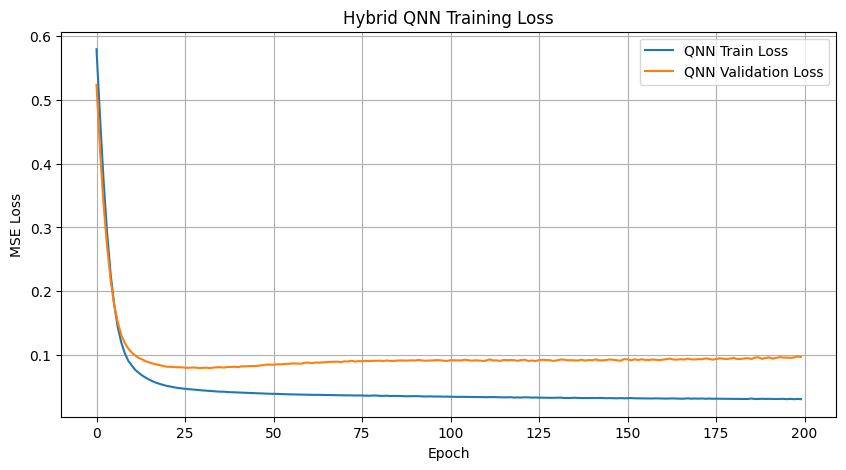

In [31]:
# =========================
# PLOT QNN TRAINING LOSS
# =========================

plt.figure(figsize=(10, 5))
plt.plot(train_losses_qnn, label="QNN Train Loss")
plt.plot(val_losses_qnn, label="QNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Hybrid QNN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

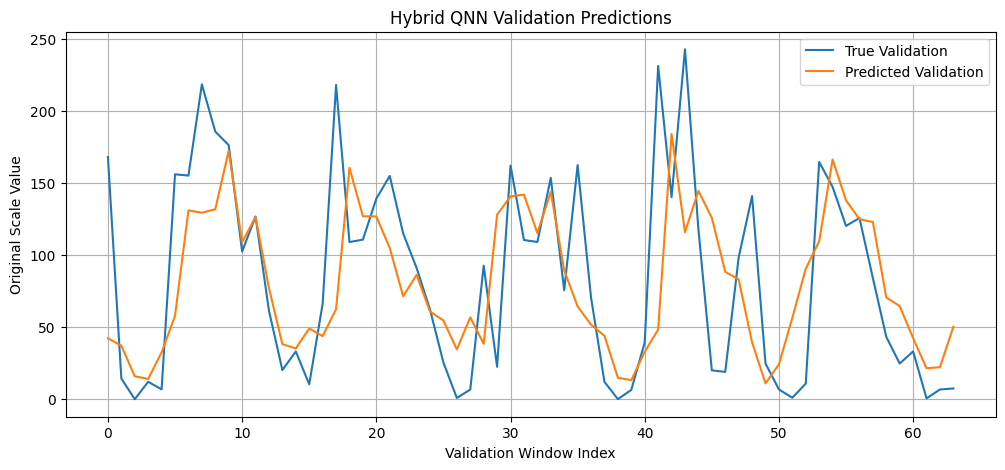

In [32]:

# VALIDATION PREDICTIONS


hybrid_model.eval()

with torch.no_grad():
    y_pred_val_scaled = hybrid_model(X_qnn_val_torch.to(device)).cpu().numpy()

y_val_scaled = y_qnn_val_torch.cpu().numpy()

scaler = lstm_results["scaler"]

y_pred_val_original = scaler.inverse_transform(
    y_pred_val_scaled.reshape(-1, 1)
).flatten()

y_val_original = scaler.inverse_transform(
    y_val_scaled.reshape(-1, 1)
).flatten()

plt.figure(figsize=(12, 5))
plt.plot(y_val_original, label="True Validation")
plt.plot(y_pred_val_original, label="Predicted Validation")
plt.xlabel("Validation Window Index")
plt.ylabel("Original Scale Value")
plt.title("Hybrid QNN Validation Predictions")
plt.legend()
plt.grid(True)
plt.show()

In [33]:

# VALIDATION METRICS


val_mse_scaled = np.mean((y_pred_val_scaled - y_val_scaled) ** 2)
val_rmse_scaled = np.sqrt(val_mse_scaled)

val_mse_original = np.mean((y_pred_val_original - y_val_original) ** 2)
val_rmse_original = np.sqrt(val_mse_original)

val_mae_original = np.mean(np.abs(y_pred_val_original - y_val_original))

print("Validation MSE scaled:", val_mse_scaled)
print("Validation RMSE scaled:", val_rmse_scaled)

print("Validation MSE original:", val_mse_original)
print("Validation RMSE original:", val_rmse_original)
print("Validation MAE original:", val_mae_original)

Validation MSE scaled: 0.07943073109164761
Validation RMSE scaled: 0.2818345810784184
Validation MSE original: 3177.229
Validation RMSE original: 56.366913
Validation MAE original: 39.993774
